In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import scipy.stats as stats
from sklearn.feature_selection import mutual_info_classif

In [7]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

In [8]:
train.drop(columns=['id'], inplace=True)

In [9]:
train.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 700000 non-null  int64  
 1   alcohol_consumption_per_week        700000 non-null  int64  
 2   physical_activity_minutes_per_week  700000 non-null  int64  
 3   diet_score                          700000 non-null  float64
 4   sleep_hours_per_day                 700000 non-null  float64
 5   screen_time_hours_per_day           700000 non-null  float64
 6   bmi                                 700000 non-null  float64
 7   waist_to_hip_ratio                  700000 non-null  float64
 8   systolic_bp                         700000 non-null  int64  
 9   diastolic_bp                        700000 non-null  int64  
 10  heart_rate                          700000 non-null  int64  
 11  cholesterol_total         

In [11]:
num_cols = train.select_dtypes(include='number').columns
cat_cols = train.select_dtypes(exclude='number').columns

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'alcohol_consumption_per_week'}>,
        <Axes: title={'center': 'physical_activity_minutes_per_week'}>,
        <Axes: title={'center': 'diet_score'}>],
       [<Axes: title={'center': 'sleep_hours_per_day'}>,
        <Axes: title={'center': 'screen_time_hours_per_day'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'waist_to_hip_ratio'}>],
       [<Axes: title={'center': 'systolic_bp'}>,
        <Axes: title={'center': 'diastolic_bp'}>,
        <Axes: title={'center': 'heart_rate'}>,
        <Axes: title={'center': 'cholesterol_total'}>],
       [<Axes: title={'center': 'hdl_cholesterol'}>,
        <Axes: title={'center': 'ldl_cholesterol'}>,
        <Axes: title={'center': 'triglycerides'}>,
        <Axes: title={'center': 'family_history_diabetes'}>],
       [<Axes: title={'center': 'hypertension_history'}>,
        <Axes: title={'center': 'cardiovascular_history'}>,
        <Axes:

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'alcohol_consumption_per_week'}>,
        <Axes: title={'center': 'physical_activity_minutes_per_week'}>,
        <Axes: title={'center': 'diet_score'}>],
       [<Axes: title={'center': 'sleep_hours_per_day'}>,
        <Axes: title={'center': 'screen_time_hours_per_day'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'waist_to_hip_ratio'}>],
       [<Axes: title={'center': 'systolic_bp'}>,
        <Axes: title={'center': 'diastolic_bp'}>,
        <Axes: title={'center': 'heart_rate'}>,
        <Axes: title={'center': 'cholesterol_total'}>],
       [<Axes: title={'center': 'hdl_cholesterol'}>,
        <Axes: title={'center': 'ldl_cholesterol'}>,
        <Axes: title={'center': 'triglycerides'}>,
        <Axes: title={'center': 'family_history_diabetes'}>],
       [<Axes: title={'center': 'hypertension_history'}>,
        <Axes: title={'center': 'cardiovascular_history'}>,
        <Axes:

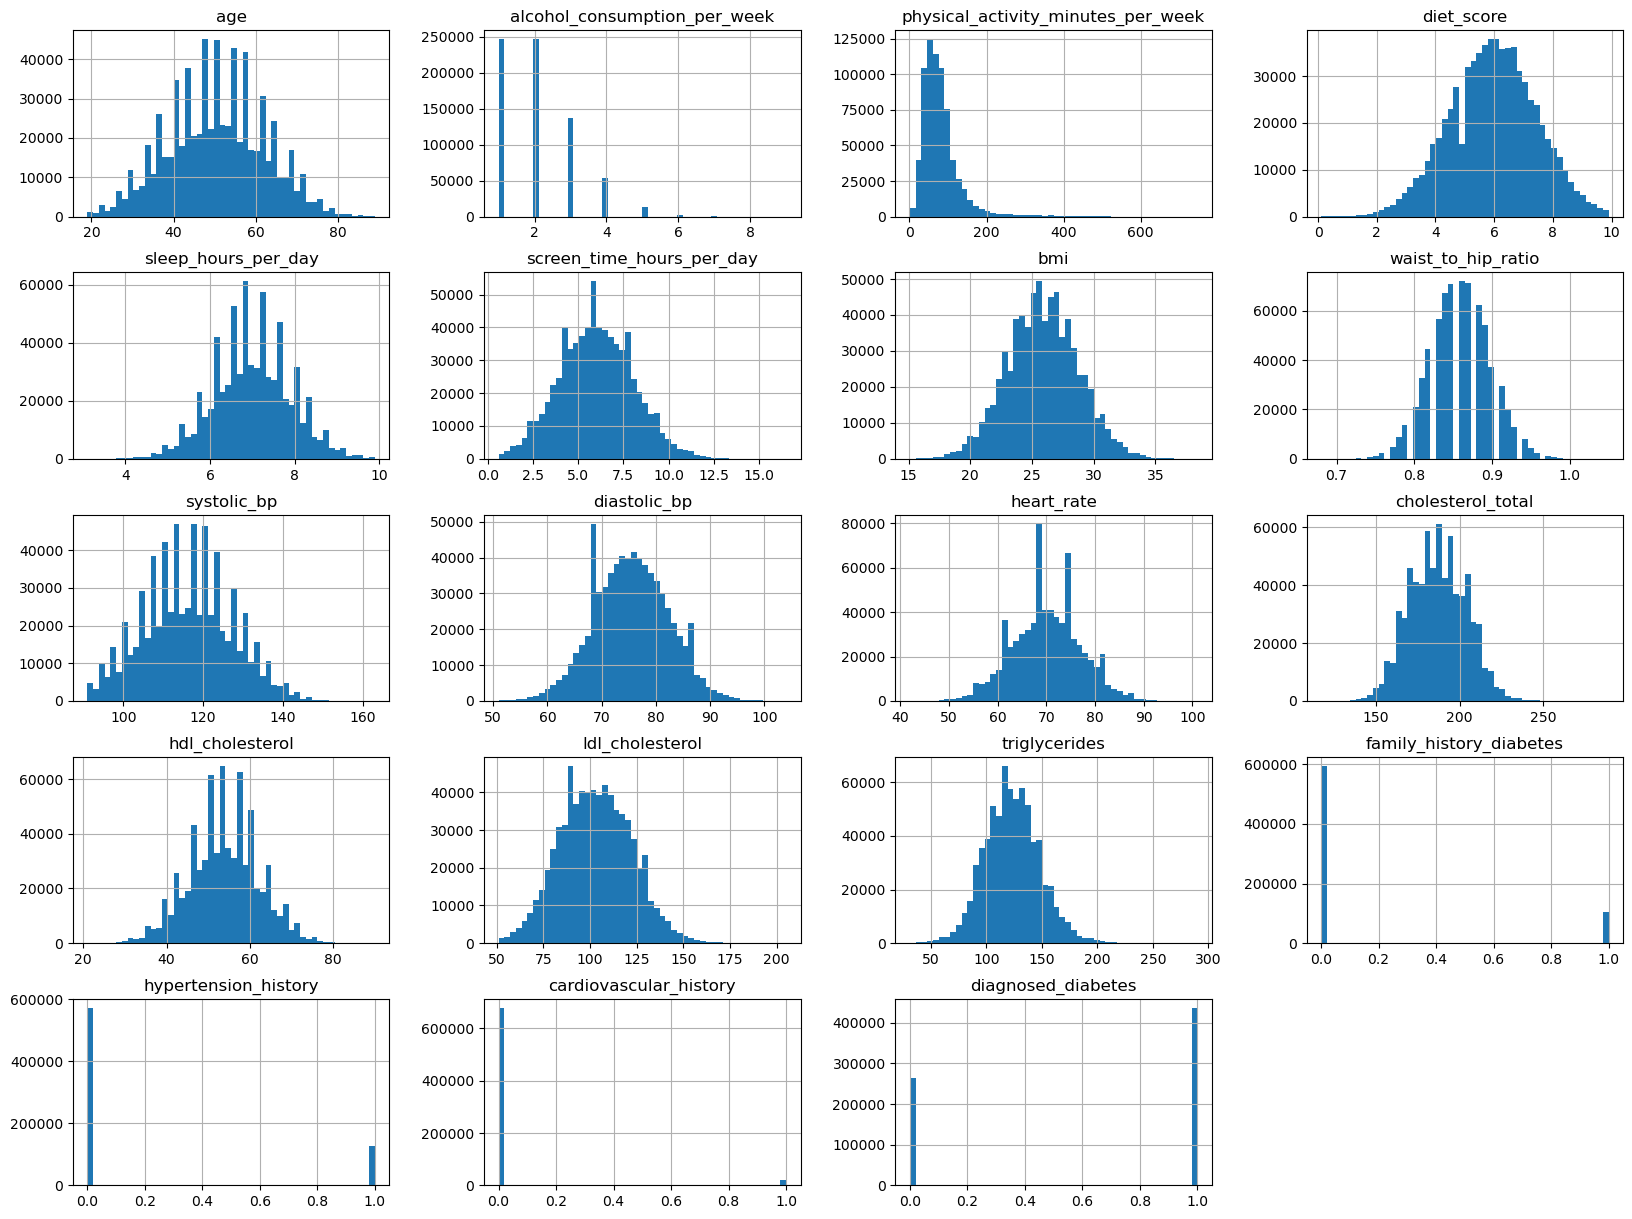

In [12]:
train[num_cols].hist(bins=50, figsize=(20,15))

ideas:
1. Apply SMOTE to balance target classes "diagnosed_diabetes"
2. Mostly normal distribution. already good
3. 

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2860342150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

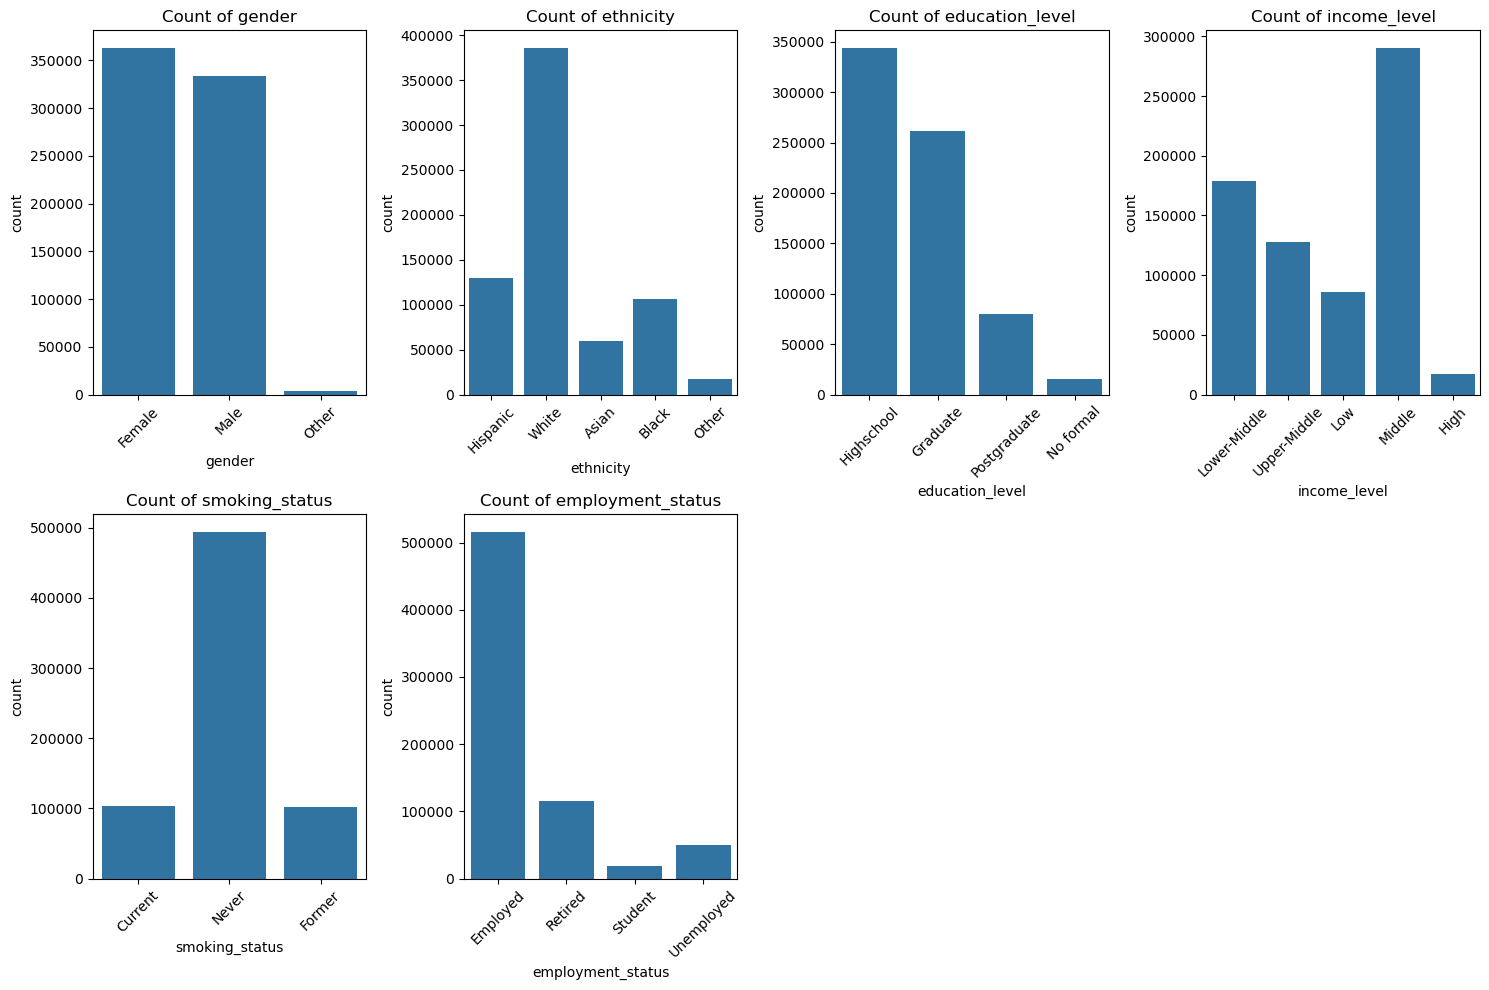

In [13]:
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i,col in enumerate(cat_cols):
    sns.countplot(x=col, data=train, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

    # train[col].value_counts().plot(kind='bar', figsize=(10, 6))
    # plt.show()
    # sns.countplot(x=col, data=train)
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [14]:
print((train['diagnosed_diabetes']==1.0).sum())
print((train['diagnosed_diabetes']==0.0).sum())

# show rate for each class
print(f"Rate of diagnosed diabetes: {(train['diagnosed_diabetes']==1.0).mean():.2%}")
print(f"Rate of not diagnosed diabetes: {(train['diagnosed_diabetes']==0.0).mean():.2%}")

436307
263693
Rate of diagnosed diabetes: 62.33%
Rate of not diagnosed diabetes: 37.67%


## Visualize the distribution of numerical features with respect to the target variable

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/468073035.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=train, x=col, hue='diagnosed_diabetes', common_norm=False)


/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/468073035.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=train, x=col, hue='diagnosed_diabetes', common_norm=False)


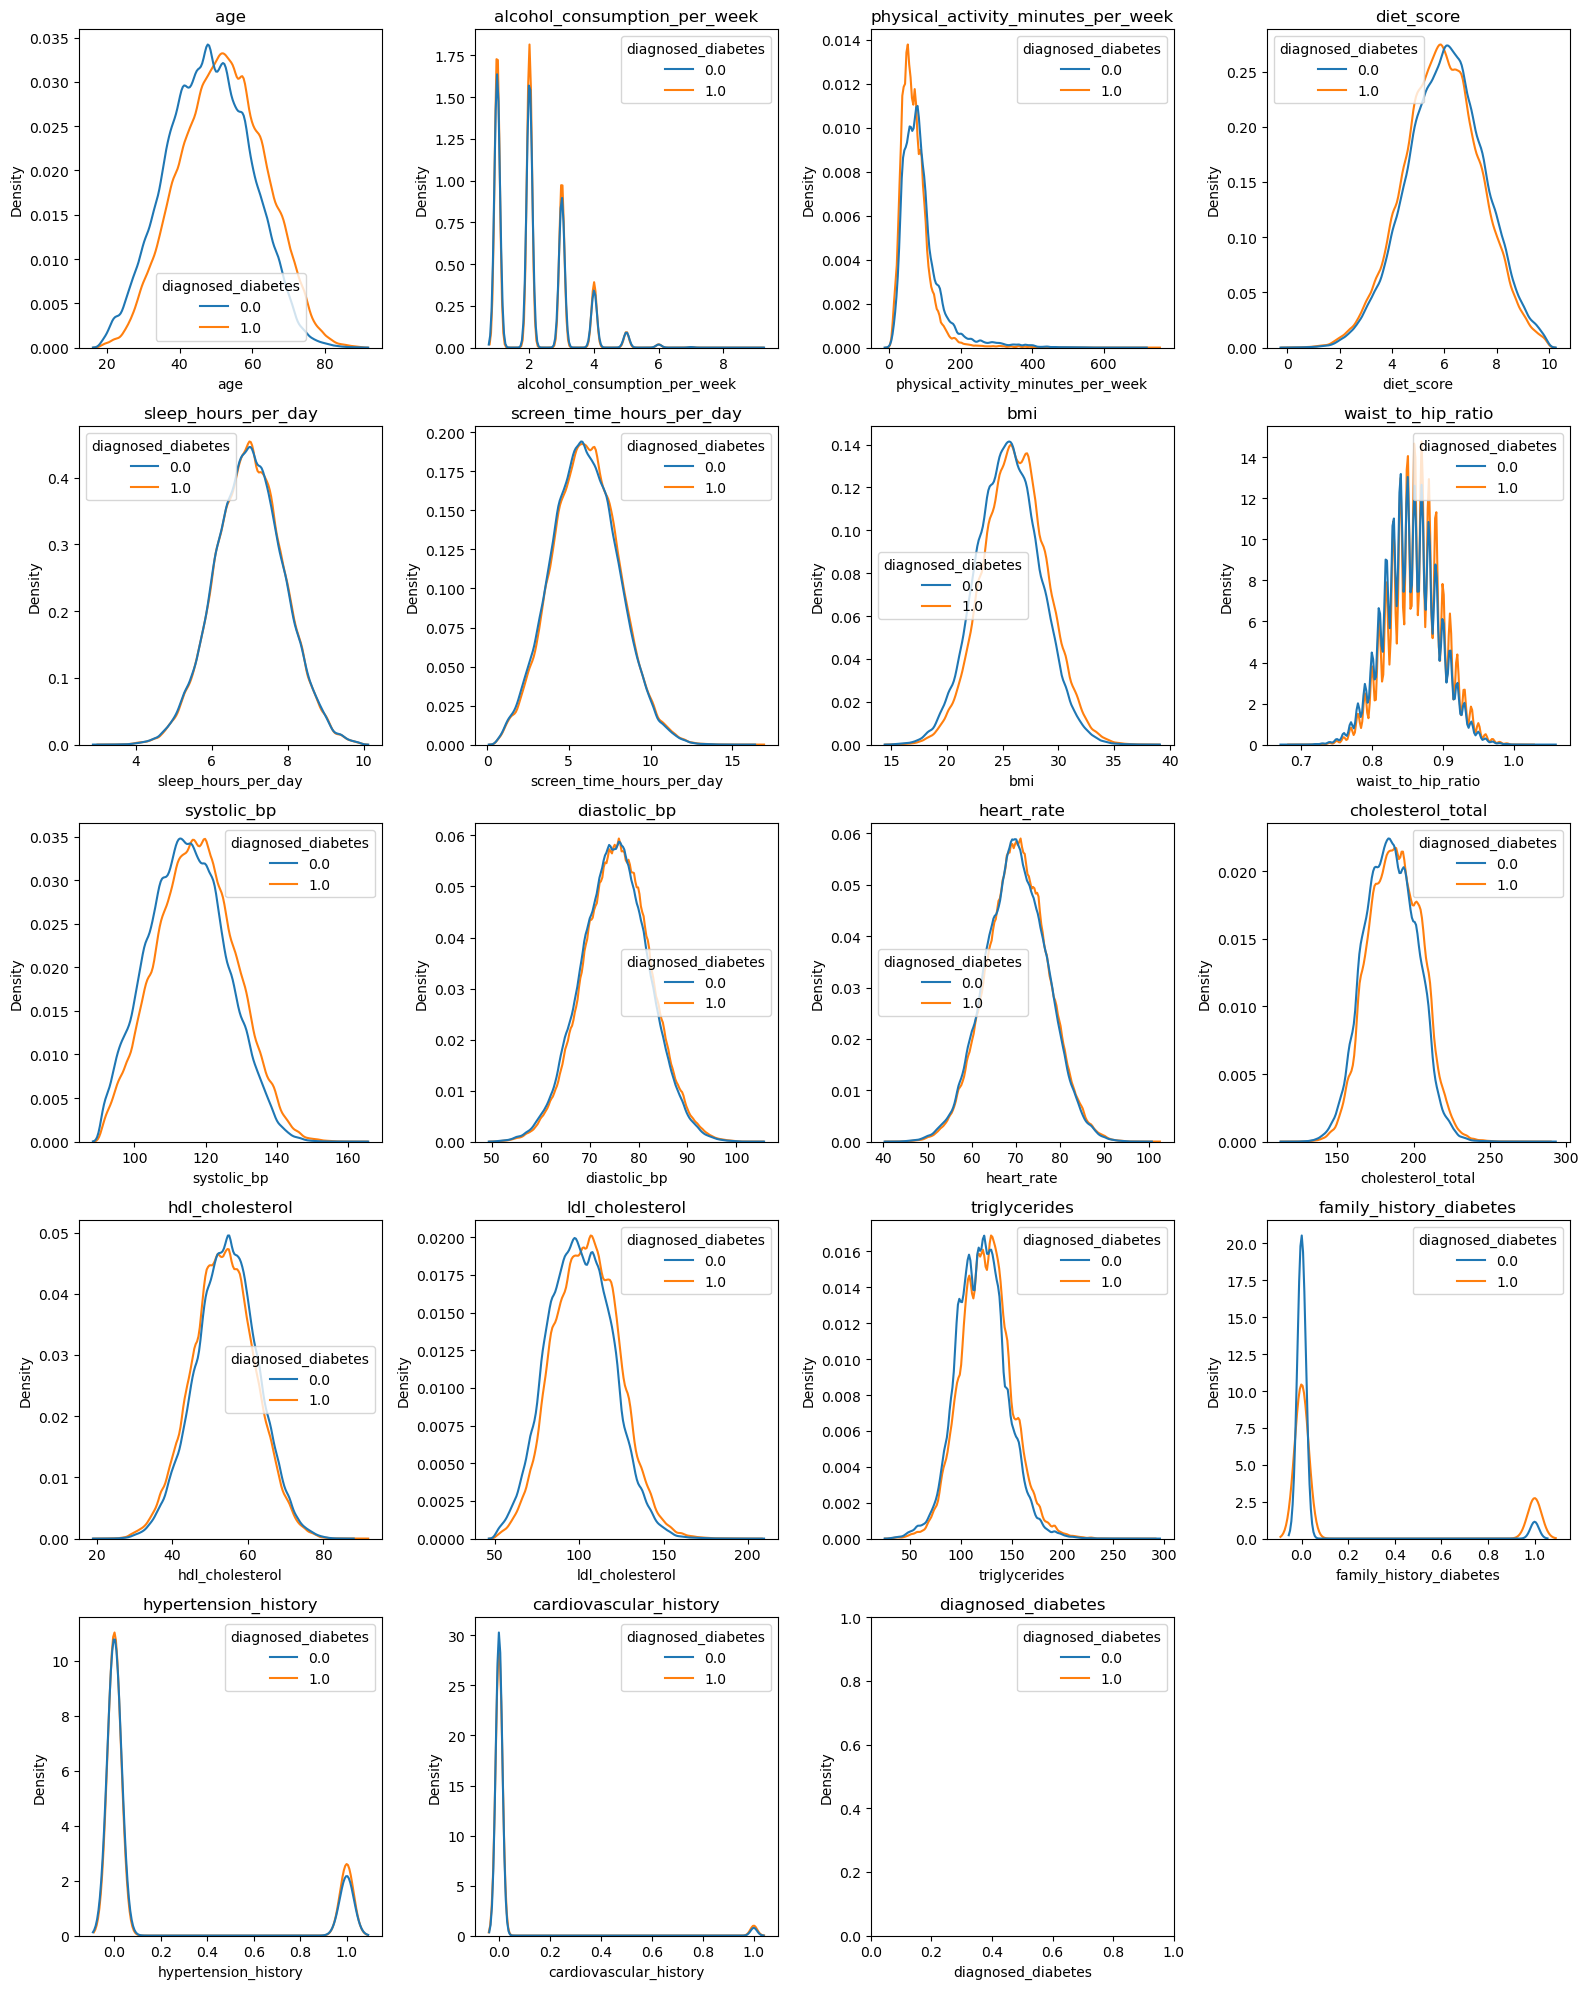

In [15]:
n_features = len(num_cols)
cols = 4
rows = math.ceil(n_features / cols)
plt.figure(figsize=(16, rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.kdeplot(data=train, x=col, hue='diagnosed_diabetes', common_norm=False)
    plt.title(col)
plt.tight_layout()
plt.show()

<h3>
Based on the KDE plots, physical_activity_minutes_per_week appears to have a threshold-like relationship with the target. <br>
The separation between diabetic and non-diabetic groups is more visible in the low-activity range, while the two distributions overlap much more at higher values. <br>
This suggests that the distinction is driven more by activity level categories than by a purely linear effect, which motivates binning. In addition, the feature is strongly right-skewed with a long upper tail, so a log1p transformation is also reasonable to compress extreme values.

The age distribution shows a clear rightward shift for the diabetic group, but the two curves maintain a similar overall shape. This suggests that diabetes risk may increase across age ranges rather than through a single constant linear effect. Therefore, binning age is a reasonable way to capture step-like risk differences across age groups.

The alcohol_consumption_per_week feature is discrete and shows separation only at certain levels rather than across a smooth continuous trend. This makes it a suitable candidate for binning, since grouped categories may better reflect its relationship with the target.

The triglycerides distribution has a noticeable right tail, indicating the presence of relatively large values that may disproportionately influence linear models. A log1p transformation is therefore justified to reduce skewness and stabilize the scale while preserving the ordering of the observations.
</h3>

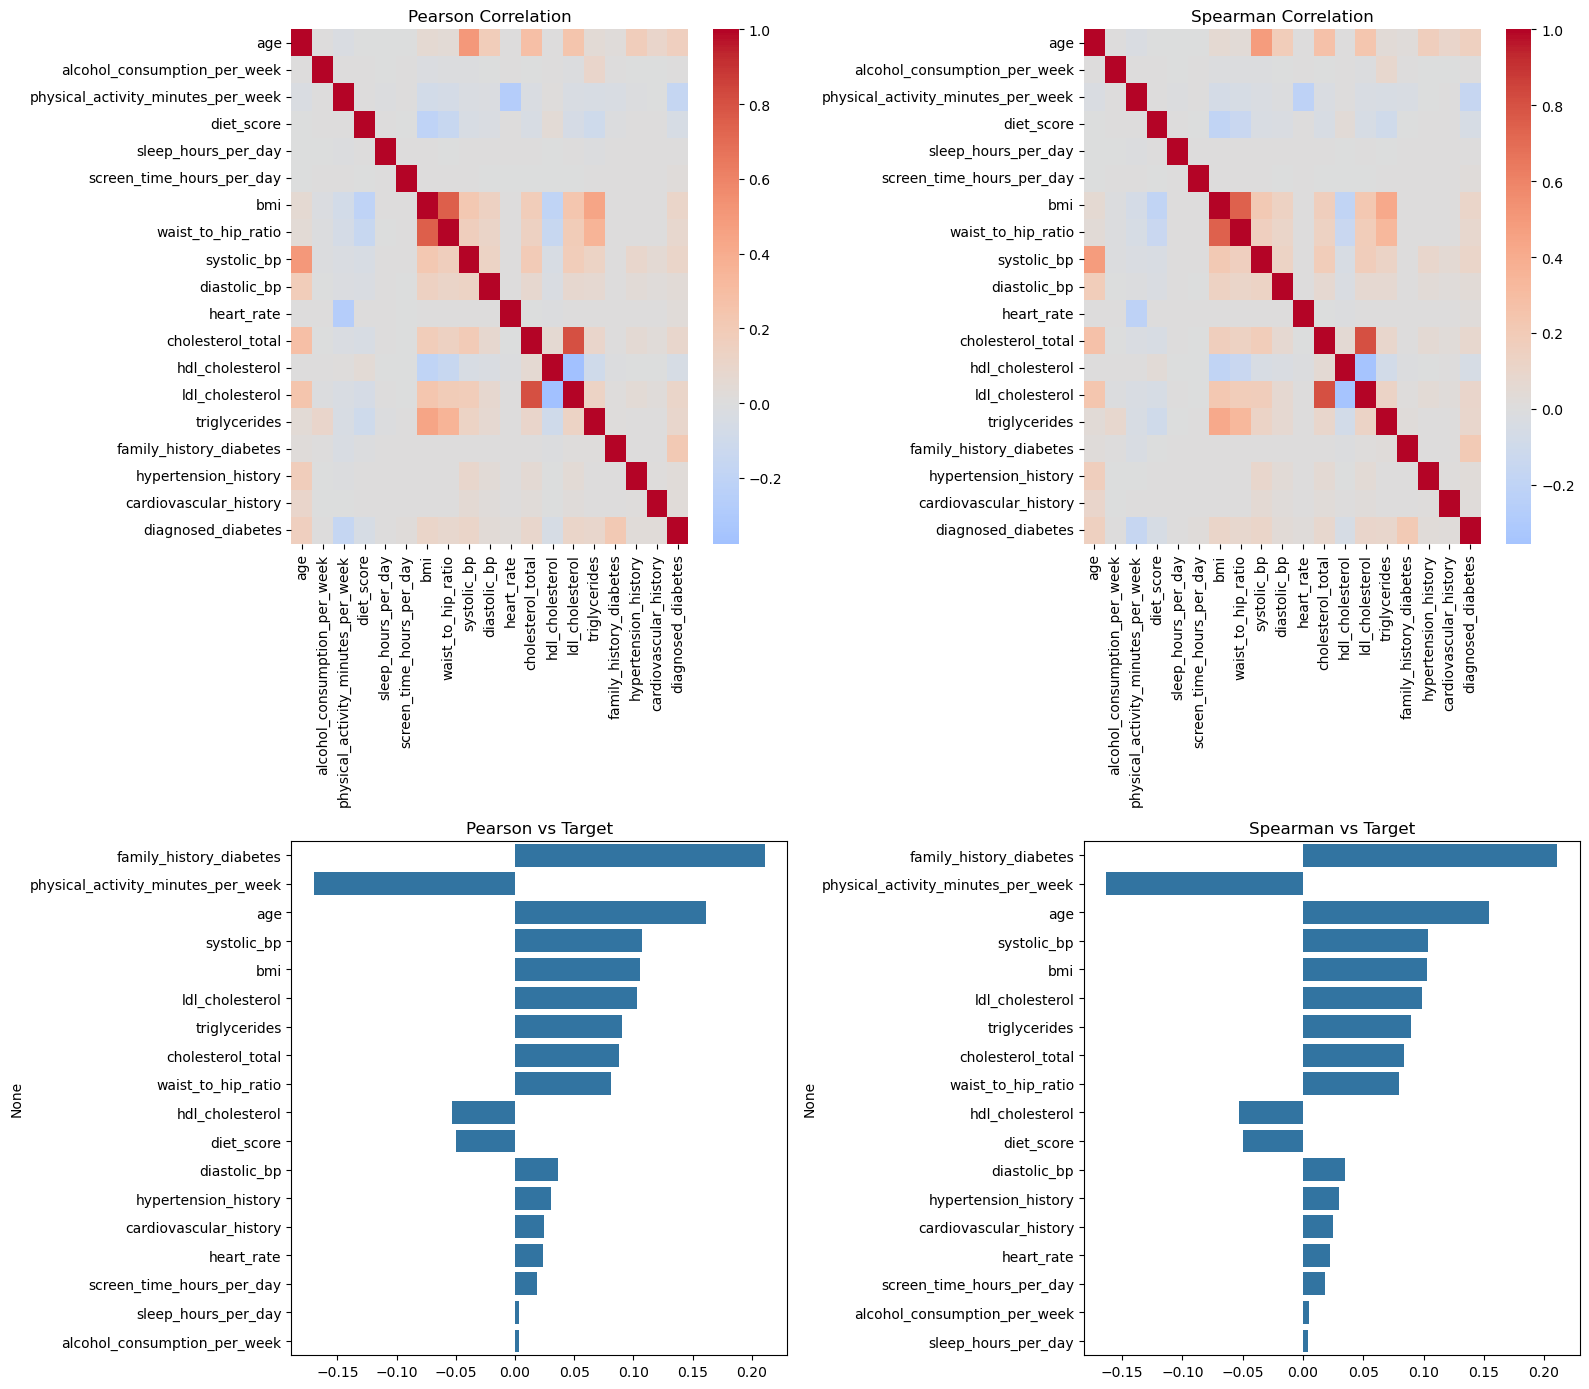

In [16]:
target_col = 'diagnosed_diabetes'

# numeric only
corr_pearson = train.corr(method='pearson', numeric_only=True)
corr_spearman = train.corr(method='spearman', numeric_only=True)

# target
target_corr_pearson = corr_pearson[target_col].drop(target_col)\
    .sort_values(key=lambda x: x.abs(), ascending=False)

target_corr_spearman = corr_spearman[target_col].drop(target_col)\
    .sort_values(key=lambda x: x.abs(), ascending=False)

# ---------- subplot ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1️⃣ Pearson heatmap
sns.heatmap(corr_pearson, cmap="coolwarm", center=0, ax=axes[0,0])
axes[0,0].set_title("Pearson Correlation")

# 2️⃣ Spearman heatmap
sns.heatmap(corr_spearman, cmap="coolwarm", center=0, ax=axes[0,1])
axes[0,1].set_title("Spearman Correlation")

# 3️⃣ Pearson vs Target
sns.barplot(x=target_corr_pearson.values,
            y=target_corr_pearson.index,
            ax=axes[1,0])
axes[1,0].set_title("Pearson vs Target")

# 4️⃣ Spearman vs Target
sns.barplot(x=target_corr_spearman.values,
            y=target_corr_spearman.index,
            ax=axes[1,1])
axes[1,1].set_title("Spearman vs Target")

plt.tight_layout()
plt.show()

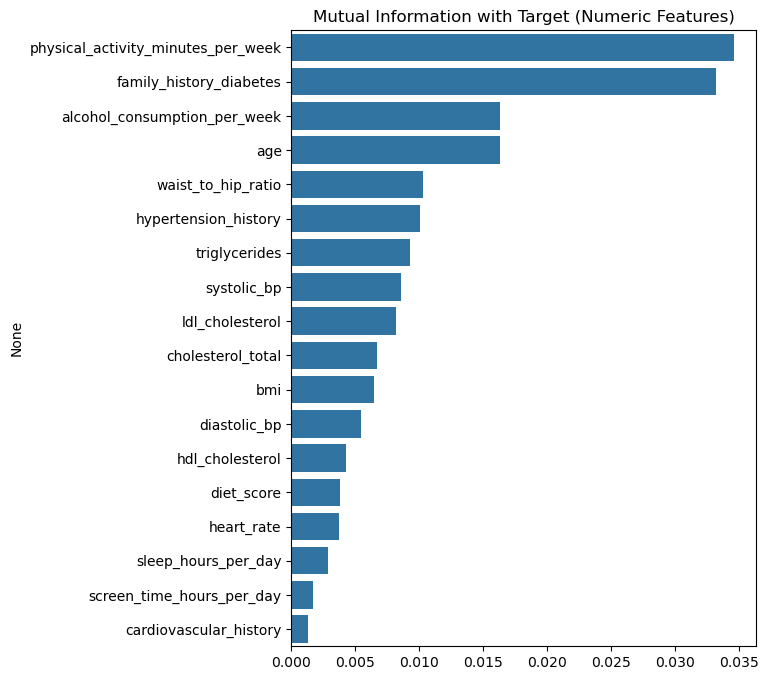

physical_activity_minutes_per_week    0.034629
family_history_diabetes               0.033193
alcohol_consumption_per_week          0.016296
age                                   0.016283
waist_to_hip_ratio                    0.010281
hypertension_history                  0.010038
triglycerides                         0.009259
systolic_bp                           0.008558
ldl_cholesterol                       0.008155
cholesterol_total                     0.006677
bmi                                   0.006494
diastolic_bp                          0.005431
hdl_cholesterol                       0.004301
diet_score                            0.003777
heart_rate                            0.003743
sleep_hours_per_day                   0.002835
screen_time_hours_per_day             0.001651
cardiovascular_history                0.001270
dtype: float64


In [17]:
# use numeric features only for MI
X_num = train.select_dtypes(include=['int64', 'float64']).drop(columns=['diagnosed_diabetes'])

y = train['diagnosed_diabetes']

# numeric-only median imputation
X_num = X_num.fillna(X_num.median())

mi = mutual_info_classif(X_num, y, random_state=42)

mi_series = pd.Series(mi, index=X_num.columns).sort_values(ascending=False)

plt.figure(figsize=(6, 8))
sns.barplot(x=mi_series.values, y=mi_series.index)
plt.title("Mutual Information with Target (Numeric Features)")
plt.show()

print(mi_series)

## [Correlation Analysis Summary]

<h3>
Pearson correlation analysis shows that most features have weak to moderate linear relationships with the target variable (diagnosed_diabetes). The strongest linear relationship is observed in family_history_diabetes, followed by age, systolic blood pressure, BMI, and lipid-related features.

However, several features such as physical_activity_minutes_per_week and alcohol_consumption_per_week exhibit relatively low Pearson correlation but high mutual information scores. This indicates that these features have nonlinear relationships with the target variable that are not captured by linear correlation.

  

In particular:
- physical_activity_minutes_per_week shows the highest mutual information score despite only moderate negative Pearson correlation, suggesting a nonlinear or threshold-based effect.
- alcohol_consumption_per_week has near-zero Pearson correlation but relatively high mutual information, implying hidden patterns not captured by linear analysis.

Overall, no single feature strongly dominates prediction. Instead, multiple moderately informative features contribute collectively, suggesting that diabetes risk is driven by complex interactions between lifestyle, physiological, and medical history factors.
</h3>

## Candidate features with relatively lower correlation but high mutual information
<h3><pre>
Such features can be used to make interaction features.
- alcohol_consumption_per_week: 0 correlation but high MI
- physical_activity: moderate correlation but the highest MI
- waist_to_hip_ratio: moderate correlation but higher MI
</pre></h3>

## Candidate features to be dropped
<h3><pre>
features with low correlation and mutual information are candidates for removal:    
- sleep_hours_per_day
- screen_time_hours_per_day
</pre></h3>

In [18]:
from itertools import combinations
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select features from MI and Pearson
top_mi = mi_series.head(6).index.tolist()
top_corr = target_corr_pearson.head(6).index.tolist()

selected_features = list(set(top_mi + top_corr))
print("Selected features before filtering:", selected_features)

# Keep only non-binary numeric features
non_binary_features = []

for col in selected_features:
    if pd.api.types.is_numeric_dtype(train[col]):
        unique_values = train[col].dropna().unique()
        if len(unique_values) > 2:
            non_binary_features.append(col)

print("Selected non-binary features:", non_binary_features)

# Create pairwise interaction features
train_auto = train.copy()
interaction_cols = []

for f1, f2 in combinations(non_binary_features, 2):
    new_col = f"{f1}_x_{f2}"
    train_auto[new_col] = train_auto[f1] * train_auto[f2]
    interaction_cols.append(new_col)

print("Generated interactions:", len(interaction_cols))
print("Sample interactions:", interaction_cols[:10])

# Evaluate interaction features with Pearson and Spearman
pearson_inter = {}
spearman_inter = {}

for col in interaction_cols:
    pearson_inter[col] = train_auto[[col, target_col]].corr(method="pearson").iloc[0, 1]
    spearman_inter[col] = train_auto[[col, target_col]].corr(method="spearman").iloc[0, 1]

pearson_inter_series = pd.Series(pearson_inter).sort_values(
    key=lambda x: x.abs(), ascending=False
)

spearman_inter_series = pd.Series(spearman_inter).sort_values(
    key=lambda x: x.abs(), ascending=False
)

print("Top Pearson interaction features:")
print(pearson_inter_series.head(10))

print("\nTop Spearman interaction features:")
print(spearman_inter_series.head(10))

Selected features before filtering: ['physical_activity_minutes_per_week', 'age', 'alcohol_consumption_per_week', 'bmi', 'systolic_bp', 'hypertension_history', 'waist_to_hip_ratio', 'family_history_diabetes', 'ldl_cholesterol']
Selected non-binary features: ['physical_activity_minutes_per_week', 'age', 'alcohol_consumption_per_week', 'bmi', 'systolic_bp', 'waist_to_hip_ratio', 'ldl_cholesterol']
Generated interactions: 21
Sample interactions: ['physical_activity_minutes_per_week_x_age', 'physical_activity_minutes_per_week_x_alcohol_consumption_per_week', 'physical_activity_minutes_per_week_x_bmi', 'physical_activity_minutes_per_week_x_systolic_bp', 'physical_activity_minutes_per_week_x_waist_to_hip_ratio', 'physical_activity_minutes_per_week_x_ldl_cholesterol', 'age_x_alcohol_consumption_per_week', 'age_x_bmi', 'age_x_systolic_bp', 'age_x_waist_to_hip_ratio']
Top Pearson interaction features:
age_x_bmi                                                  0.184644
age_x_waist_to_hip_ratio  

In [19]:
# Evaluate interaction features with Mutual Information
X_inter = train_auto[interaction_cols].copy()
X_inter = X_inter.fillna(X_inter.median())

mi_inter = mutual_info_classif(X_inter, y, random_state=42)
mi_inter_series = pd.Series(mi_inter, index=interaction_cols).sort_values(ascending=False)

print("\nTop MI interaction features:")
print(mi_inter_series.head(10))

# Combine results
interaction_summary = pd.DataFrame({
    "pearson": pearson_inter_series,
    "spearman": spearman_inter_series,
    "mi": mi_inter_series
})

interaction_summary["abs_pearson"] = interaction_summary["pearson"].abs()
interaction_summary["abs_spearman"] = interaction_summary["spearman"].abs()

interaction_summary = interaction_summary.sort_values(
    by=["mi", "abs_pearson", "abs_spearman"],
    ascending=False
)

print("\nTop interaction candidates:")
print(interaction_summary.head(10))

top_interactions = interaction_summary.head(5).index.tolist()
print("\nTop interaction candidates:", top_interactions)


Top MI interaction features:
physical_activity_minutes_per_week_x_waist_to_hip_ratio              0.034461
physical_activity_minutes_per_week_x_systolic_bp                     0.031784
physical_activity_minutes_per_week_x_bmi                             0.029924
physical_activity_minutes_per_week_x_alcohol_consumption_per_week    0.022656
physical_activity_minutes_per_week_x_ldl_cholesterol                 0.022343
physical_activity_minutes_per_week_x_age                             0.020231
age_x_bmi                                                            0.019071
age_x_waist_to_hip_ratio                                             0.018130
age_x_ldl_cholesterol                                                0.016306
age_x_systolic_bp                                                    0.014971
dtype: float64

Top interaction candidates:
                                                     pearson  spearman  \
physical_activity_minutes_per_week_x_waist_to_h... -0.164663 -0.156337  

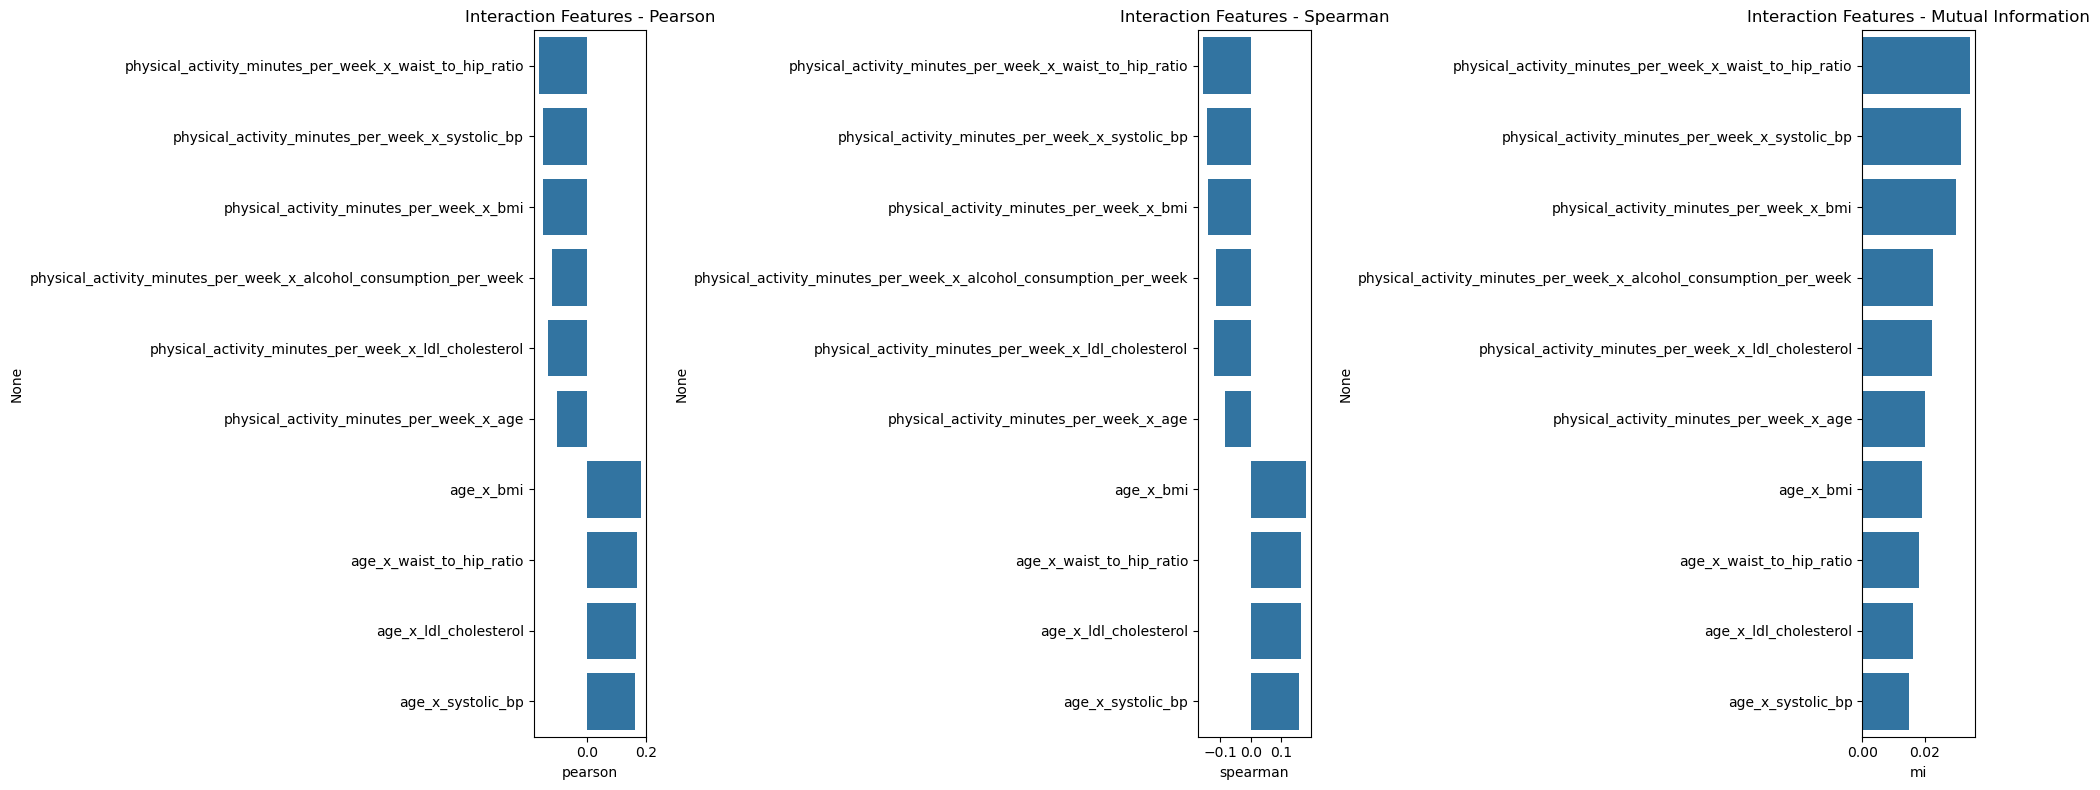

In [20]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
plot_df = interaction_summary.head(10)

sns.barplot(x=plot_df["pearson"], y=plot_df.index, ax=axes[0])
axes[0].set_title("Interaction Features - Pearson")

sns.barplot(x=plot_df["spearman"], y=plot_df.index, ax=axes[1])
axes[1].set_title("Interaction Features - Spearman")

sns.barplot(x=plot_df["mi"], y=plot_df.index, ax=axes[2])
axes[2].set_title("Interaction Features - Mutual Information")

plt.tight_layout()
plt.show()

<h3>
To identify meaningful interaction features, pairwise products were generated among features selected from both Pearson correlation and mutual information analysis. Binary variables were excluded to avoid masking-type interactions.  <br><br>  
    
The strongest interaction candidates consistently involved physical activity, including waist-to-hip ratio × physical activity, systolic blood pressure × physical activity, and BMI × physical activity. This suggests that physical activity may modify the effect of physiological and metabolic risk factors on diabetes prediction.  <br><br>

Among these, BMI × physical activity and waist-to-hip ratio × physical activity were prioritized because they showed strong signal across Pearson, Spearman, and mutual information, while also being clinically interpretable.
</h3>

Created interaction features: ['bmi_x_activity', 'age_x_bmi', 'whr_x_bmi', 'trig_x_chol', 'activity_x_age', 'alcohol_x_bmi']


Created interaction features: ['bmi_x_activity', 'age_x_bmi', 'whr_x_bmi', 'trig_x_chol', 'activity_x_age', 'alcohol_x_bmi']


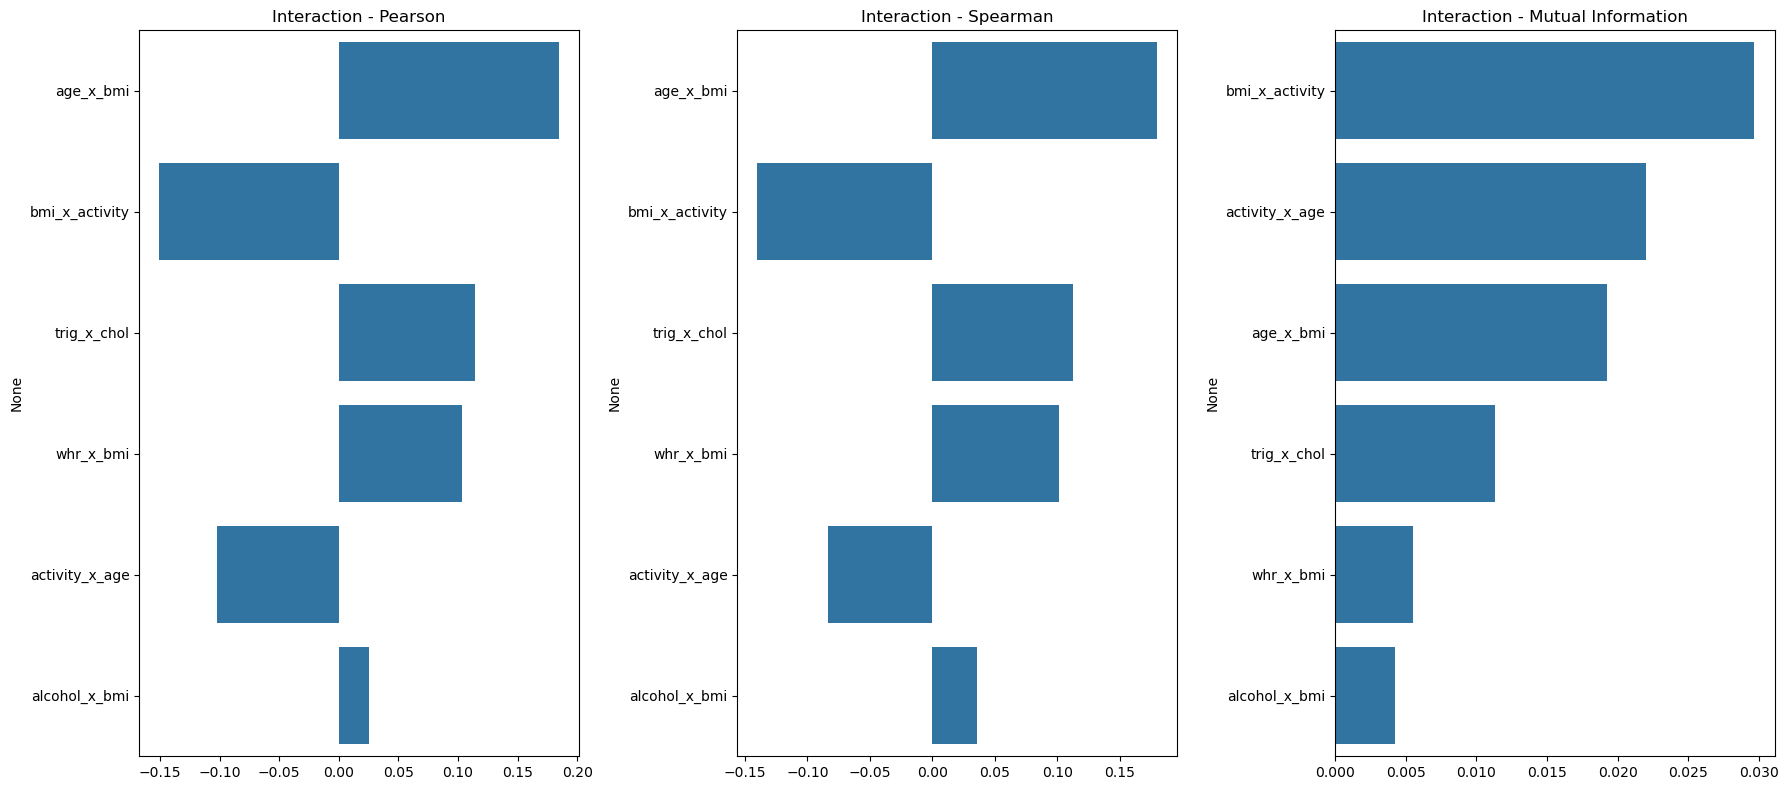

                 pearson  spearman        mi  abs_pearson  abs_spearman
bmi_x_activity -0.150679 -0.140160  0.029630     0.150679      0.140160
activity_x_age -0.101848 -0.083816  0.021998     0.101848      0.083816
age_x_bmi       0.184644  0.179757  0.019252     0.184644      0.179757
trig_x_chol     0.113986  0.112619  0.011291     0.113986      0.112619
whr_x_bmi       0.103586  0.101773  0.005505     0.103586      0.101773
alcohol_x_bmi   0.025299  0.036201  0.004264     0.025299      0.036201


In [21]:
# =========================
# 1. Create interaction
# =========================

train_inter = train.copy()  

interaction_dict = {
    'bmi_x_activity': ('bmi', 'physical_activity_minutes_per_week'),
    'age_x_bmi': ('age', 'bmi'),
    'whr_x_bmi': ('waist_to_hip_ratio', 'bmi'),
    'trig_x_chol': ('triglycerides', 'cholesterol_total'),
    'activity_x_age': ('physical_activity_minutes_per_week', 'age'),
    'alcohol_x_bmi': ('alcohol_consumption_per_week', 'bmi')
}

created_features = []

for new_col, (col1, col2) in interaction_dict.items():
    if col1 in train_inter.columns and col2 in train_inter.columns:
        train_inter[new_col] = train_inter[col1] * train_inter[col2]  
        created_features.append(new_col)

print("Created interaction features:", created_features)

# =========================
# 2. Pearson / Spearman for interaction features
# =========================

pearson_inter = {}
spearman_inter = {}

for col in created_features:
    pearson_inter[col] = train_inter[[col, target_col]].corr(method='pearson').iloc[0,1]
    spearman_inter[col] = train_inter[[col, target_col]].corr(method='spearman').iloc[0,1]

pearson_inter = pd.Series(pearson_inter).sort_values(key=lambda x: x.abs(), ascending=False)
spearman_inter = pd.Series(spearman_inter).sort_values(key=lambda x: x.abs(), ascending=False)

# =========================
# 3. Mutual Information for interaction features
# =========================

X_inter = train_inter[created_features].copy()  
X_inter = X_inter.fillna(X_inter.median())      

mi_inter = mutual_info_classif(X_inter, y, random_state=42)
mi_inter = pd.Series(mi_inter, index=created_features).sort_values(ascending=False)

# =========================
# 4. Visualzation
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Pearson
sns.barplot(x=pearson_inter.values, y=pearson_inter.index, ax=axes[0])
axes[0].set_title("Interaction - Pearson")

# Spearman
sns.barplot(x=spearman_inter.values, y=spearman_inter.index, ax=axes[1])
axes[1].set_title("Interaction - Spearman")

# MI
sns.barplot(x=mi_inter.values, y=mi_inter.index, ax=axes[2])
axes[2].set_title("Interaction - Mutual Information")

plt.tight_layout()
plt.show()

# =========================
# 5. summary table
# =========================

interaction_summary = pd.DataFrame({
    'pearson': pearson_inter,
    'spearman': spearman_inter,
    'mi': mi_inter
})

interaction_summary['abs_pearson'] = interaction_summary['pearson'].abs()
interaction_summary['abs_spearman'] = interaction_summary['spearman'].abs()

interaction_summary = interaction_summary.sort_values(
    by=['mi', 'abs_pearson', 'abs_spearman'],
    ascending=False
)

print(interaction_summary)

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2254184835.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  id_bin_mean = train_eda.groupby('id_bin')['diagnosed_diabetes'].mean()


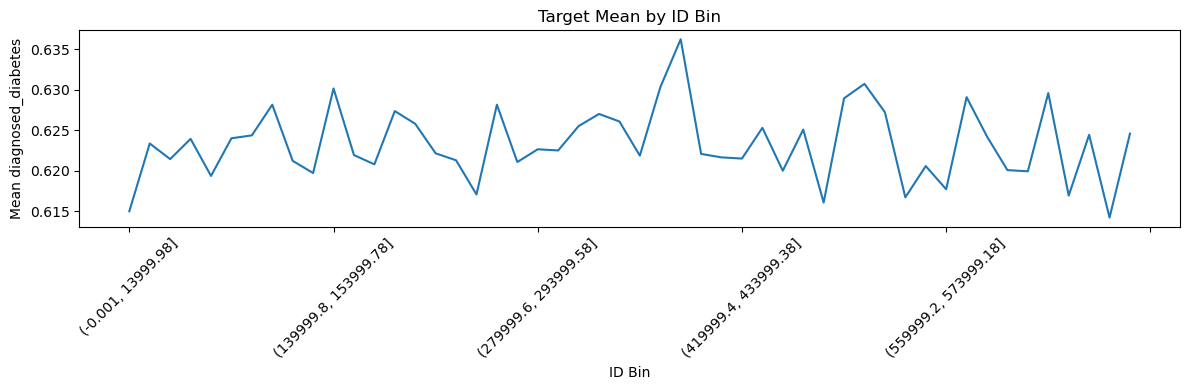

In [28]:
train_eda = train.copy()

# binning id
train_eda['id_bin'] = pd.qcut(train_eda['id'], 50)

id_bin_mean = train_eda.groupby('id_bin')['diagnosed_diabetes'].mean()

plt.figure(figsize=(12,4))
id_bin_mean.plot()
plt.title("Target Mean by ID Bin")
plt.ylabel("Mean diagnosed_diabetes")
plt.xlabel("ID Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

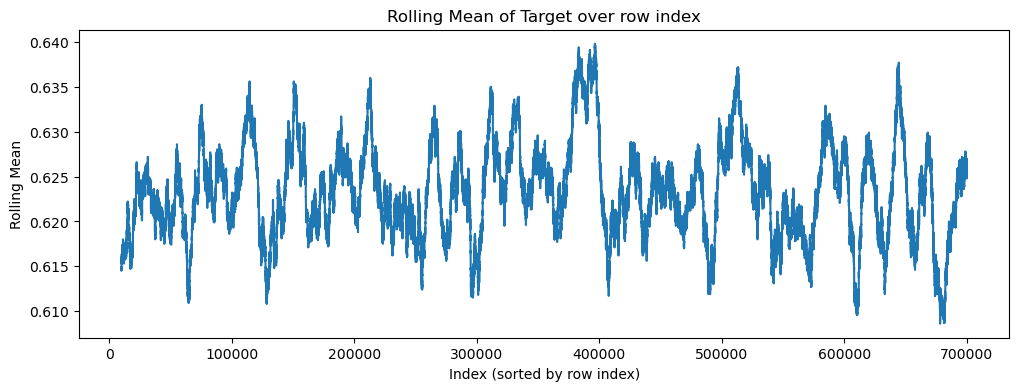

In [29]:
train_sorted = train.sort_values('id')

rolling_mean = train_sorted['diagnosed_diabetes'].rolling(10000).mean()

plt.figure(figsize=(12,4))
plt.plot(rolling_mean)
plt.title("Rolling Mean of Target over ID")
plt.ylabel("Rolling Mean")
plt.xlabel("Index (sorted by ID)")
plt.show()

In [30]:
n = len(train_sorted)

early = train_sorted.iloc[:n//3]['diagnosed_diabetes']
late = train_sorted.iloc[-n//3:]['diagnosed_diabetes']

print("Early mean:", early.mean())
print("Late mean:", late.mean())

Early mean: 0.6229851756931082
Late mean: 0.622613935388756


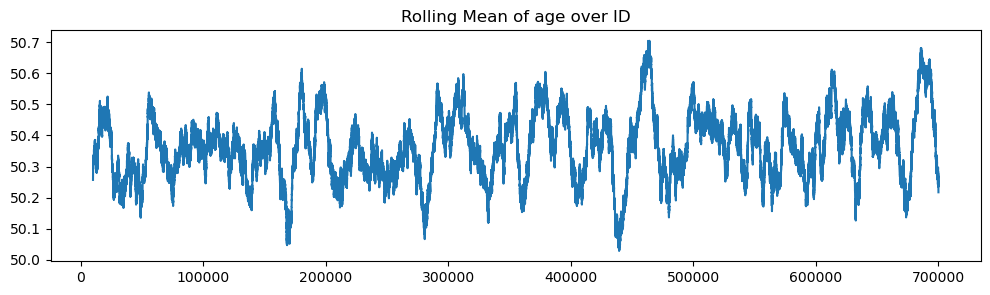

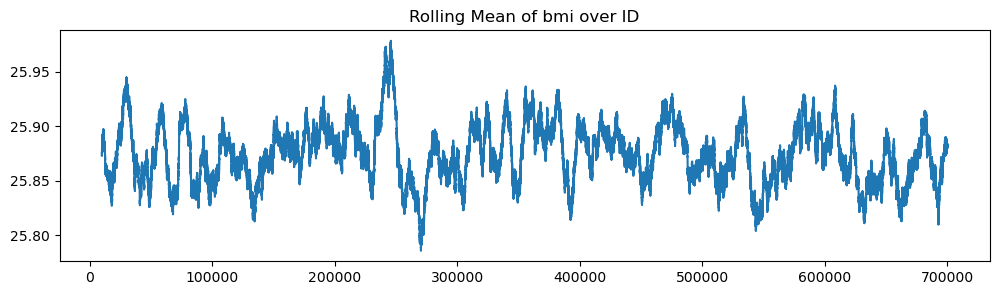

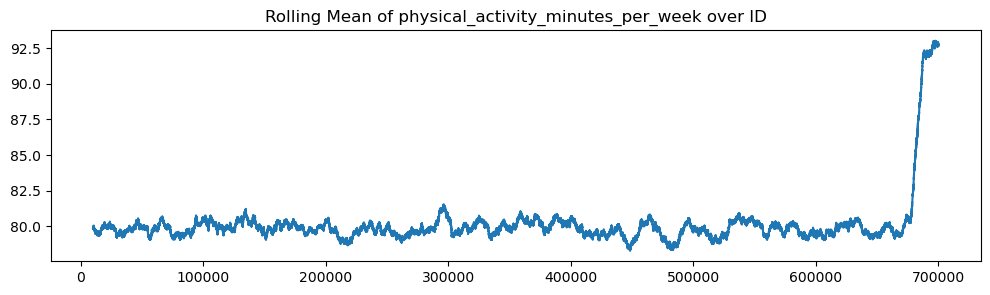

In [ ]:
features_to_check = [
    'age',
    'bmi',
    'physical_activity_minutes_per_week'
]

for col in features_to_check:
    rolling_feat = train_sorted[col].rolling(10000).mean()

    plt.figure(figsize=(12,3))
    plt.plot(rolling_feat)
    plt.title(f"Rolling Mean of {col} over ID")
    plt.show()

## Binary LDA note

For binary `diagnosed_diabetes`, `LinearDiscriminantAnalysis` can only produce at most `n_classes - 1 = 1` discriminant component.

The safe pattern used below is:
- compute `max_lda_components = min(n_features, n_classes - 1)`
- set `n_components = min(2, max_lda_components)`
- if only one component is available, visualize it with a 1D histogram or density plot instead of a 2D scatter

This is the correct way to apply LDA in your binary classification setting.

LDA components shape: (700000, 1)
Explained variance ratio: [1.]


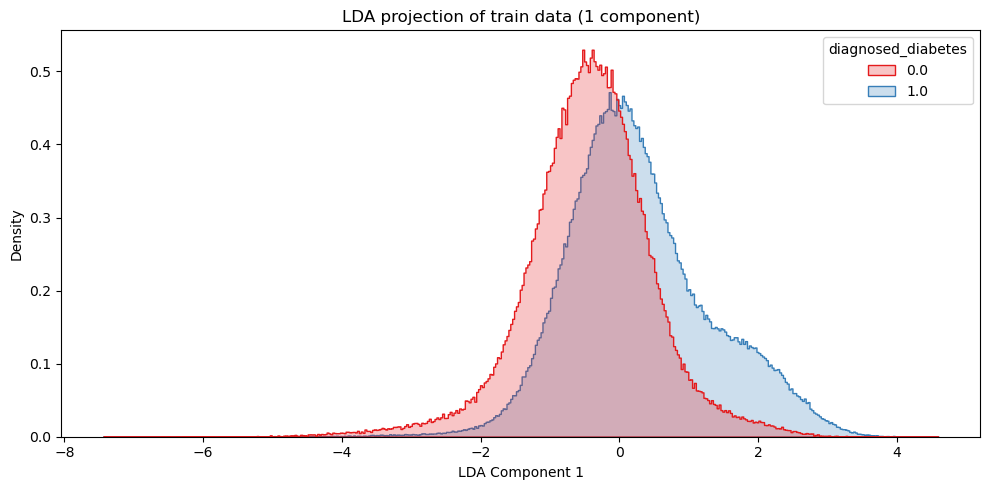


Top positive contributions to LDA1:
family_history_diabetes      0.464777
age                          0.313284
triglycerides                0.104661
bmi                          0.099752
ldl_cholesterol              0.054013
screen_time_hours_per_day    0.040570
cholesterol_total            0.025619
cardiovascular_history       0.020649
systolic_bp                  0.020083
sleep_hours_per_day          0.005121
dtype: float64

Top negative contributions to LDA1:
physical_activity_minutes_per_week   -0.362329
diet_score                           -0.072343
hdl_cholesterol                      -0.061733
heart_rate                           -0.048932
diastolic_bp                         -0.017361
waist_to_hip_ratio                   -0.002463
alcohol_consumption_per_week         -0.001472
hypertension_history                  0.000595
sleep_hours_per_day                   0.005121
systolic_bp                           0.020083
dtype: float64


In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Prepare numeric feature matrix and target vector for LDA
feature_cols = train.select_dtypes(include=['number']).columns.drop('diagnosed_diabetes')
X = train[feature_cols]
y = train['diagnosed_diabetes']

# Standardize features before LDA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Select LDA components safely based on class and feature counts
n_classes = len(np.unique(y))
max_lda_components = min(X_scaled.shape[1], n_classes - 1)
n_components = min(2, max_lda_components)

if n_components < 1:
    raise ValueError('Unable to fit LDA: need at least 2 classes and one feature.')

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_lda = lda.fit_transform(X_scaled, y)

print('LDA components shape:', X_lda.shape)
print('Explained variance ratio:', lda.explained_variance_ratio_)

lda_cols = [f'LDA{i}' for i in range(1, X_lda.shape[1] + 1)]
lda_df = pd.DataFrame(X_lda, columns=lda_cols)
lda_df['diagnosed_diabetes'] = y.values

if X_lda.shape[1] >= 2:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='LDA1',
        y='LDA2',
        hue='diagnosed_diabetes',
        palette='Set1',
        alpha=0.7,
        data=lda_df,
        edgecolor='k',
        s=55
    )
    plt.title('LDA projection of train data (2 components)')
    plt.xlabel('LDA Component 1')
    plt.ylabel('LDA Component 2')
    plt.legend(title='diagnosed_diabetes')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=lda_df,
        x='LDA1',
        hue='diagnosed_diabetes',
        element='step',
        stat='density',
        common_norm=False,
        palette='Set1'
    )
    plt.title('LDA projection of train data (1 component)')
    plt.xlabel('LDA Component 1')
    plt.tight_layout()
    plt.show()

# Show top feature contributions for the first component
loadings = pd.Series(lda.coef_[0], index=feature_cols)
print('\nTop positive contributions to LDA1:')
print(loadings.sort_values(ascending=False).head(10))
print('\nTop negative contributions to LDA1:')
print(loadings.sort_values().head(10))

QDA 5-fold CV AUC: 0.6846 ± 0.0014


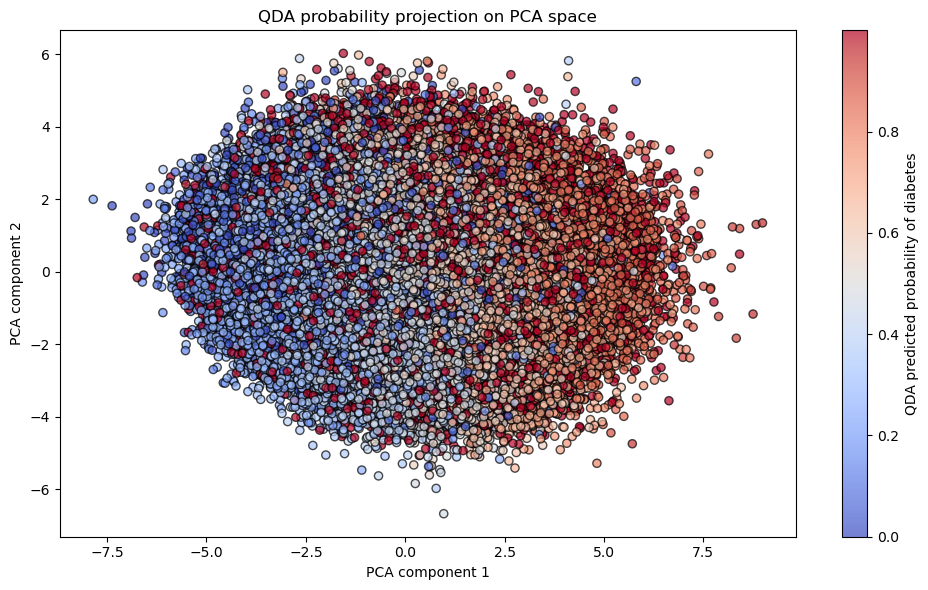

QDA class priors: [0.37670429 0.62329571]
Top 10 features by absolute QDA coefficients (approx):
QDA does not expose linear coefficients for this fit.


In [38]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare numeric feature matrix and target vector
feature_cols = train.select_dtypes(include=['number']).columns.drop('diagnosed_diabetes')
X = train[feature_cols]
y = train['diagnosed_diabetes']

# Standardize numeric features for QDA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
cv_auc = cross_val_score(qda, X_scaled, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"QDA 5-fold CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

qda.fit(X_scaled, y)

# Visualize QDA probability surface using PCA projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
qda_probs = qda.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=qda_probs,
    cmap='coolwarm',
    alpha=0.7,
    s=35,
    edgecolor='k'
)
plt.colorbar(label='QDA predicted probability of diabetes')
plt.title('QDA probability projection on PCA space')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.tight_layout()
plt.show()

print('QDA class priors:', qda.priors_)
print('Top 10 features by absolute QDA coefficients (approx):')
if hasattr(qda, 'coef_'):
    coefs = pd.Series(np.abs(qda.coef_[0]), index=feature_cols).sort_values(ascending=False)
    print(coefs.head(10))
else:
    print('QDA does not expose linear coefficients for this fit.')

/opt/anaconda3/envs/dml/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


       mean_auc   std_auc  mean_accuracy  std_accuracy
model                                                 
LDA    0.694133  0.001446       0.662917      0.001733
QDA    0.684646  0.001411       0.626637      0.000904


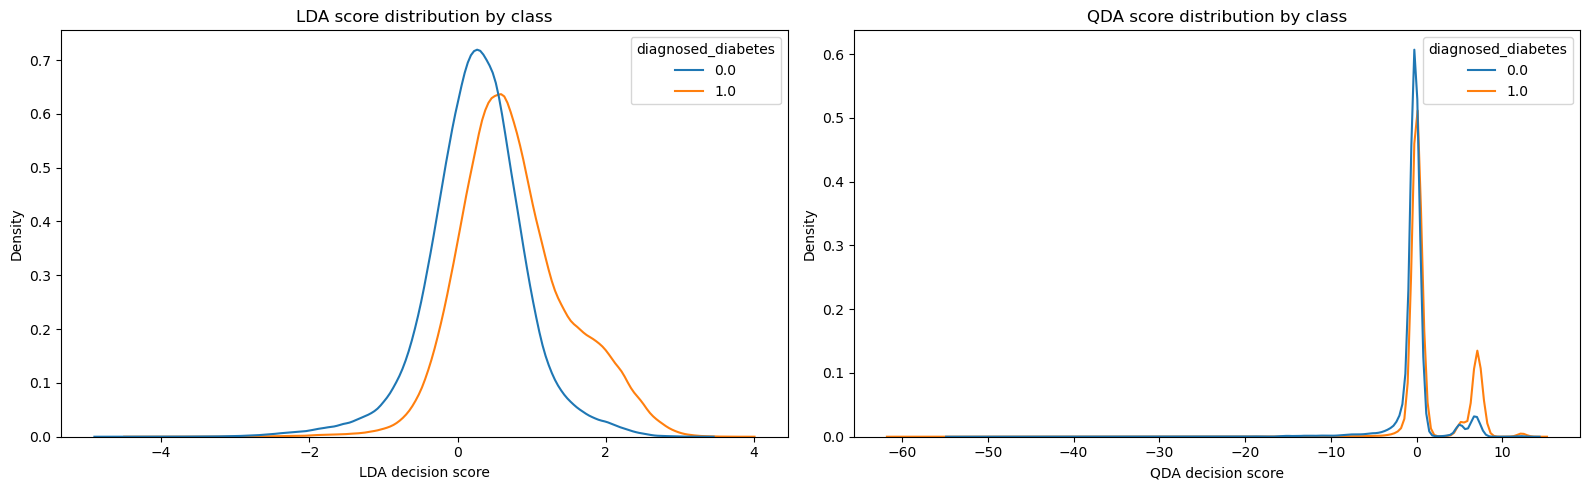

In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

feature_cols = train.select_dtypes(include=['number']).columns.drop('diagnosed_diabetes')
X = train[feature_cols].fillna(train[feature_cols].median())
y = train['diagnosed_diabetes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis(reg_param=0.01)

models = {
    'LDA': lda,
    'QDA': qda
}

comparison = []
for name, model in models.items():
    auc_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc', n_jobs=-1)
    acc_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy', n_jobs=-1)
    comparison.append({
        'model': name,
        'mean_auc': auc_scores.mean(),
        'std_auc': auc_scores.std(),
        'mean_accuracy': acc_scores.mean(),
        'std_accuracy': acc_scores.std()
    })

comparison_df = pd.DataFrame(comparison).set_index('model')
print(comparison_df)

# Fit both models on full data for score visualization
lda.fit(X_scaled, y)
qda.fit(X_scaled, y)

score_df = pd.DataFrame({
    'LDA_score': lda.decision_function(X_scaled),
    'QDA_score': qda.decision_function(X_scaled),
    'diagnosed_diabetes': y.values
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(
    data=score_df,
    x='LDA_score',
    hue='diagnosed_diabetes',
    common_norm=False,
    fill=False,
    ax=axes[0]
)
axes[0].set_title('LDA score distribution by class')
axes[0].set_xlabel('LDA decision score')

sns.kdeplot(
    data=score_df,
    x='QDA_score',
    hue='diagnosed_diabetes',
    common_norm=False,
    fill=False,
    ax=axes[1]
)
axes[1].set_title('QDA score distribution by class')
axes[1].set_xlabel('QDA decision score')

plt.tight_layout()
plt.show()

/var/folders/k_/643yxrvd3xxb0md9scf224bc0000gp/T/ipykernel_42614/2119840546.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=explained_variance.index, y=explained_variance.values, palette='viridis')


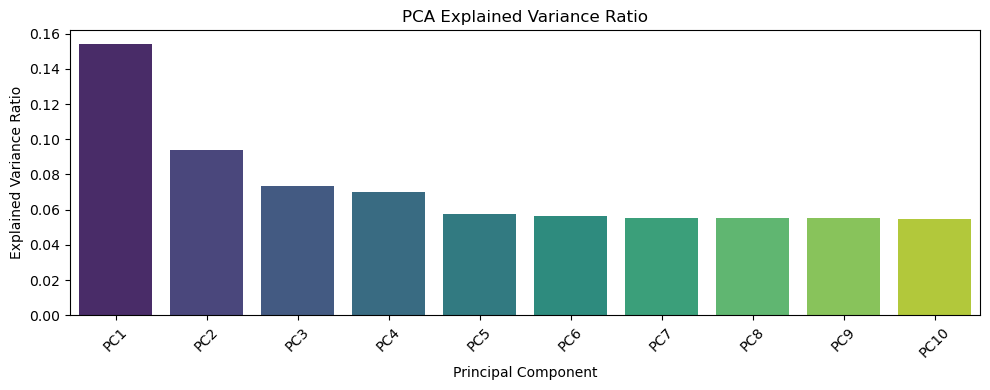

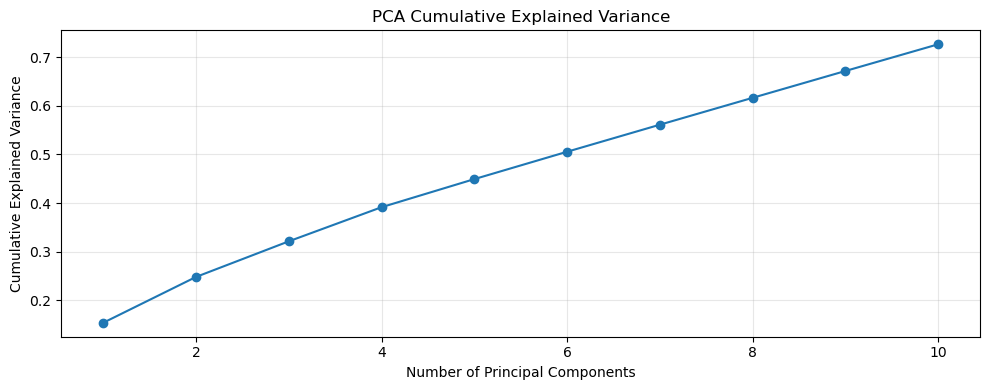

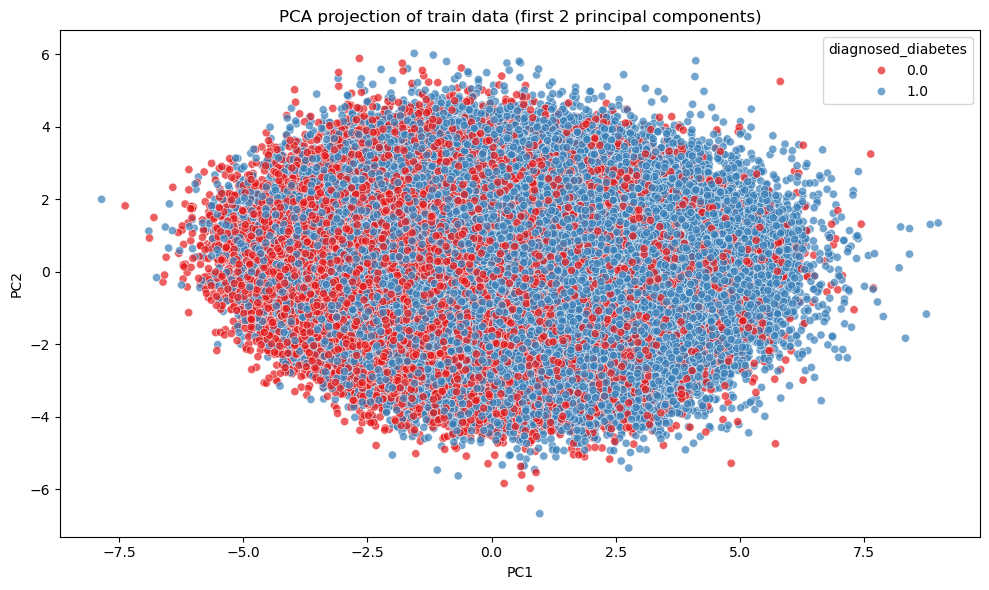

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare numeric features for PCA
feature_cols = train.select_dtypes(include=['number']).columns.drop('diagnosed_diabetes')
X = train[feature_cols].fillna(train[feature_cols].median())

target = train['diagnosed_diabetes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=[f'PC{i}' for i in range(1, len(pca.explained_variance_ratio_)+1)]
)

plt.figure(figsize=(10, 4))
sns.barplot(x=explained_variance.index, y=explained_variance.values, palette='viridis')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
cumulative_variance = np.cumsum(explained_variance.values)
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['diagnosed_diabetes'] = target.values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='diagnosed_diabetes',
    palette='Set1',
    alpha=0.7,
    s=35
)
plt.title('PCA projection of train data (first 2 principal components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='diagnosed_diabetes')
plt.tight_layout()
plt.show()

## UMAP projection (2D)
This cell builds a 2D UMAP embedding of the training data and colors points by `diagnosed_diabetes`.

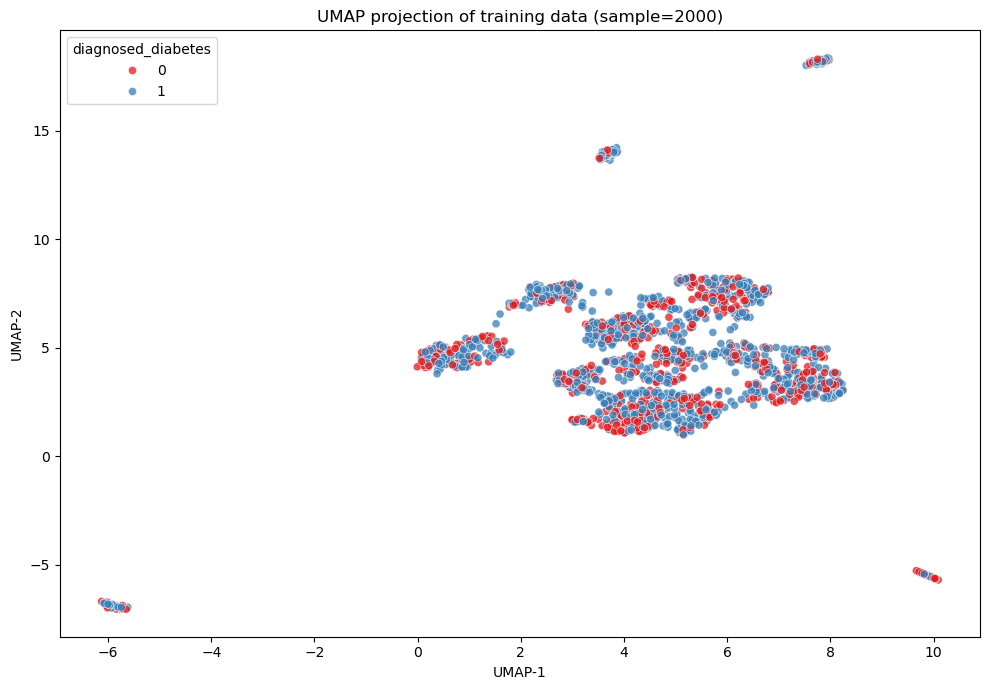

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler

# Load train if not already in memory
if 'train' not in globals():
    train = pd.read_csv('./data/train.csv')

df_umap = train.copy()

# Remove ID if present
if 'id' in df_umap.columns:
    df_umap = df_umap.drop(columns=['id'])

# Keep target for coloring
target_col = 'diagnosed_diabetes'
y_umap = df_umap[target_col].astype(int)
X_umap = df_umap.drop(columns=[target_col])

# Encode categorical columns for UMAP distance computation
X_umap = pd.get_dummies(X_umap, drop_first=True)

# Fill missing values and scale
X_umap = X_umap.fillna(X_umap.median(numeric_only=True))

# Speed-up for notebook EDA
sample_n = min(2000, len(X_umap))
idx = X_umap.sample(n=sample_n, random_state=42).index
X_umap = X_umap.loc[idx]
y_umap = y_umap.loc[idx]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_umap)

# Fit UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    init='random',
    n_epochs=200,
    low_memory=True,
    random_state=None
)
embedding = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame({
    'UMAP-1': embedding[:, 0],
    'UMAP-2': embedding[:, 1],
    'diagnosed_diabetes': y_umap.values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=umap_df,
    x='UMAP-1',
    y='UMAP-2',
    hue='diagnosed_diabetes',
    alpha=0.75,
    s=35,
    palette='Set1'
)
plt.title(f'UMAP projection of training data (sample={sample_n})')
plt.legend(title='diagnosed_diabetes')
plt.tight_layout()
plt.show()

## ISOMAP projection (2D)
This cell builds a 2D ISOMAP embedding of the training data and colors points by `diagnosed_diabetes`.

ISOMAP preserves geodesic (manifold) distances via a neighborhood graph, while UMAP focuses more on local neighborhood structure and is usually faster/scales better.

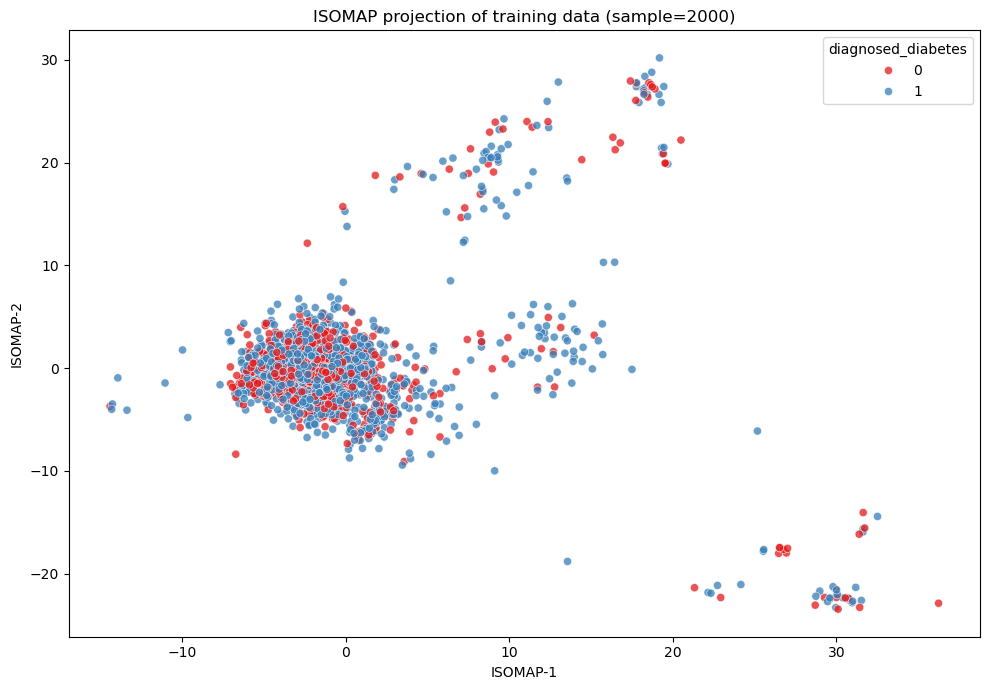

In [43]:
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load train if not already in memory
if 'train' not in globals():
    train = pd.read_csv('./data/train.csv')

df_iso = train.copy()

# Remove ID if present
if 'id' in df_iso.columns:
    df_iso = df_iso.drop(columns=['id'])

# Keep target for coloring
target_col = 'diagnosed_diabetes'
y_iso = df_iso[target_col].astype(int)
X_iso = df_iso.drop(columns=[target_col])

# Encode categorical columns
X_iso = pd.get_dummies(X_iso, drop_first=True)

# Fill missing values and scale
X_iso = X_iso.fillna(X_iso.median(numeric_only=True))

# Same sample size as UMAP for fair visual comparison
sample_n = min(2000, len(X_iso))
idx = X_iso.sample(n=sample_n, random_state=42).index
X_iso = X_iso.loc[idx]
y_iso = y_iso.loc[idx]

scaler = StandardScaler()
X_scaled_iso = scaler.fit_transform(X_iso)

# Fit ISOMAP
iso = Isomap(
    n_components=2,
    n_neighbors=15,
    metric='minkowski',
    p=2
)
embedding_iso = iso.fit_transform(X_scaled_iso)

isomap_df = pd.DataFrame({
    'ISOMAP-1': embedding_iso[:, 0],
    'ISOMAP-2': embedding_iso[:, 1],
    'diagnosed_diabetes': y_iso.values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=isomap_df,
    x='ISOMAP-1',
    y='ISOMAP-2',
    hue='diagnosed_diabetes',
    alpha=0.75,
    s=35,
    palette='Set1'
)
plt.title(f'ISOMAP projection of training data (sample={sample_n})')
plt.legend(title='diagnosed_diabetes')
plt.tight_layout()
plt.show()